In [3]:
"""
Notebook: model_advanced_mlp.ipynb
Objetivo: Realización de una prueba con un modelo MLP/DNN con early stopping
para la detección de diabetes, con el fin de comparar sus resultados con los
modelos avanzados previamente entrenados.
Autor: Jesús Rodríguez
Fecha: 03/02/2026
"""

'\nNotebook: model_advanced_mlp.ipynb\nObjetivo: Realización de una prueba con un modelo MLP/DNN con early stopping\npara la detección de diabetes, con el fin de comparar sus resultados con los\nmodelos avanzados previamente entrenados.\nAutor: Jesús Rodríguez\nFecha: 03/02/2026\n'

## 1. Configuración inicial


In [33]:
# Librerías básicas
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y métricas de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    precision_recall_curve, auc, confusion_matrix, average_precision_score,
    RocCurveDisplay, fbeta_score
)

# Interpretabilidad
from IPython.display import display

# TensorFlow / Keras para MLP/DNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# Google Drive (solo necesario si se ejecuta en Colab)
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [6]:
# Fijación de semillas para garantizar reproducibilidad experimental
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
# Carpeta y archivo de datos
data_dir = Path("data")  # ruta relativa para ejecución local
DATA_FILE = "cleaned_dataset.csv"
DATA_PATH = data_dir / DATA_FILE

# Montaje de Drive solo en Colab si el archivo no existe localmente
if IN_COLAB and not DATA_PATH.exists():
    drive.mount("/content/drive")
    data_dir = Path("/content/drive/MyDrive/TFM/data")
    DATA_PATH = data_dir / DATA_FILE

# Crear carpeta local si no existe
data_dir.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Verificar que el dataset exista
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} no existe. "
        f"Coloca el archivo en '{data_dir}' o monta Drive en Colab."
    )

# Carga del dataset
df = pd.read_csv(DATA_PATH, encoding="Latin-1")

## 2. Exploración inicial del dataset

In [9]:
# Dimensiones y tipos
print("Dimensiones del dataset:", df.shape)
print(df.info())

# Distribución inicial de DIABETE3
print("Distribución original del target:")
print(df["DIABETE3"].value_counts(normalize=True))

Dimensiones del dataset: (257709, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-null  float64
 18  _AGEG5YR  257709 non-null  float64
 19  _BMI5C

Distribución del target tras normalización:
DIABETE3
0    229318
1     28391
Name: count, dtype: int64


/tmp/ipython-input-1411977993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


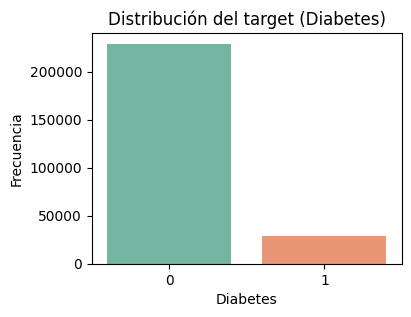

In [10]:
# Normalización del target: 1 → Diabetes, 0 → No Diabetes
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0})

# Comprobación
print("Distribución del target tras normalización:")
print(df["DIABETE3"].value_counts())

# Visualización
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución del target (Diabetes)")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.show()

## 3. Análisis Exploratorio de Datos (EDA)

El EDA completo por grupos de las variables se realizó en model_base_v1.ipynb

## 4. División del dataset

In [11]:
# pylint: disable=C0103
# pylint: disable=W0621

# Target
TARGET = "DIABETE3"

# Separación de features y target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# División: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 5. Pipelines de preprocesamiento

### 5.1. Separación por tipo de variable

In [12]:
# Variables nominales con varias categorías (para OneHot en RF)
CATEGORICAL_NOMINAL = ['BPHIGH4', '_RACE']

# Variables binarias (imputación 0/1 en determinista)
BINARY_VARS = ['BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
               'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK',
               'DIFFALON', 'DIFFDRES', 'SMOKE100', 'ADDEPEV2', 'SEX']

# Variables ordinales
CATEGORICAL_ORDINAL = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']

# Variables numéricas
NUMERIC_VARS = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']

### 5.2. Preprocesamiento determinista

In [13]:
def mlp_deterministic_preproc(X_input):
    """
    Preprocesamiento determinista para modelos Random Forest.

    - Sustituye los valores codificados como -1 por NaN.
    - Convierte las variables binarias a formato 0/1,
      asignando 0 a los valores distintos de 1.

    Args:
        X_input (pd.DataFrame): Dataset de entrada.

    Returns:
        pd.DataFrame: Dataset preprocesado.
    """
    X = X_input.copy()

    # Reemplazo global de valores -1 por NaN
    X = X.replace(-1, np.nan)

    # Normalización de variables binarias
    for col in BINARY_VARS:
        X[col] = (X[col] == 1).astype(int)

    return X

### 5.3. Preprocesamiento numérico (Capping de outliers)

In [14]:
def cap_outliers_numeric(X_input, numeric_vars):
    """
    Recorta valores extremos de variables numéricas al percentil 1 y 99.

    Args:
        X_input (pd.DataFrame): Dataset de entrada.
        numeric_vars (list): Lista de columnas numéricas a recortar.

    Returns:
        pd.DataFrame: Dataset con valores acotados.
    """
    X = X_input.copy()
    for col in numeric_vars:
        low = np.nanpercentile(X[col], 1)
        high = np.nanpercentile(X[col], 99)
        X[col] = X[col].clip(low, high)
    return X

### 5.4. Transformadores por tipo de variable

In [15]:
# Nominal: Imputación + OneHot
nominal_pipeline_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal: imputación con moda
ordinal_pipeline_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Numéricas: capping + imputación + StandardScaler
numeric_pipeline_mlp = Pipeline(steps=[
    ('cap_outliers', FunctionTransformer(
        func=cap_outliers_numeric,
        kw_args={'numeric_vars': NUMERIC_VARS},
        validate=False
    )),
    ('imputer', SimpleImputer(strategy='median')),
    # Escalado necesario solo para MLP/DNN; árboles no dependen de la escala
    ('scaler', StandardScaler())
])

### 5.5. ColumnTransformers

In [16]:
# ColumnTransformer final MLP/DNN
preprocessor_mlp = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline_mlp, CATEGORICAL_NOMINAL),
    ('bin', 'passthrough', BINARY_VARS),
    ('ord', ordinal_pipeline_mlp, CATEGORICAL_ORDINAL),
    ('num', numeric_pipeline_mlp, NUMERIC_VARS)
])

## 6. Definición de la arquitectura MLP/DNN

In [17]:
def build_mlp(input_dim: int) -> Sequential:
    """
    Construye un MLP/DNN para clasificación binaria.

    Args:
        input_dim (int): Número de features tras preprocesado.

    Returns:
        tf.keras.Sequential: Modelo MLP listo para compilar.

    Justificación:
    - Dos capas ocultas (64 y 32 nodos) con ReLU permiten capturar relaciones
      no lineales sin sobreajustar para un dataset de tamaño medio.
    - Dropout(0.2) para regularización y prevenir overfitting.
    - Capa de salida con sigmoid para predicción de probabilidad binaria.
    """
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

In [18]:
# Preprocesado de datos para MLP/DNN

# Construcción del pipeline de preprocesado MLP/DNN integrando
mlp_pipeline = Pipeline([
    ('deterministic', FunctionTransformer(mlp_deterministic_preproc)),
    ('preprocessor', preprocessor_mlp)
])

# Ajuste del pipeline con los datos de entrenamiento y se transformaron
# los conjuntos de entrenamiento, validación y test
X_train_proc = mlp_pipeline.fit_transform(X_train)
X_val_proc = mlp_pipeline.transform(X_val)
X_test_proc = mlp_pipeline.transform(X_test)

# Conversión de los datos a np.array para compatibilidad con Keras
X_train_proc = np.array(X_train_proc)
X_val_proc = np.array(X_val_proc)
X_test_proc = np.array(X_test_proc)

# El target "y" se mantiene como pandas Series. Keras lo convierte
# internamente a tensor y no requiere conversión explícita a np.array
# porque es binario y 1D;. Si fuera multiclase u object
# habría que convertir a array o tensor

# Se determinó input_dim a partir del número de features finales
input_dim_mlp = X_train_proc.shape[1]

print(f"Shape de X_train_proc: {X_train_proc.shape}")
print(f"Shape de X_val_proc: {X_val_proc.shape}")
print(f"Shape de X_test_proc: {X_test_proc.shape}")
print(f"Input dim para MLP: {input_dim_mlp}")

Shape de X_train_proc: (154625, 32)
Shape de X_val_proc: (51542, 32)
Shape de X_test_proc: (51542, 32)
Input dim para MLP: 32


In [19]:
# Construcción y compilación del MLP/DNN

# Construcción del modelo MLP/DNN utilizando la función build_mlp
mlp_model = build_mlp(input_dim=input_dim_mlp)

# Compilación del modelo definiendo el optimizador, la función de pérdida
# y la métrica principal a evaluar (AUC)
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]
)

# Resumen del modelo para verificar la arquitectura
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Definición de callbacks y early stopping

# EarlyStopping: previene overfitting y detiene el entrenamiento cuando
# la métrica de validación deja de mejorar
early_stop = EarlyStopping(
    monitor='val_auc', # el entrenamiento se detiene si deja de mejorar
    patience=10,
    mode='max', # Se maximiza el 'val_auc'
    restore_best_weights=True,
    verbose=1 # Muestra información sobre el early_stop
)

## 7. Entrenamiento y evaluación

### 7.1. Entrenamiento

In [21]:
# Cálculo de pesos de clase para tratar el desbalance
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

In [22]:
# Entrenamiento del modelo MLP/DNN con los datos procesados de entrenamiento,
# utilizando validación para monitorizar la métrica AUC
history = mlp_model.fit(
    X_train_proc,
    y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.7202 - loss: 0.6154 - val_auc: 0.8246 - val_loss: 0.4813
Epoch 2/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.8109 - loss: 0.5318 - val_auc: 0.8341 - val_loss: 0.4549
Epoch 3/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8220 - loss: 0.5171 - val_auc: 0.8382 - val_loss: 0.4485
Epoch 4/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc: 0.8264 - loss: 0.5110 - val_auc: 0.8396 - val_loss: 0.4507
Epoch 5/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.8286 - loss: 0.5080 - val_auc: 0.8407 - val_loss: 0.4386
Epoch 6/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.8306 - loss: 0.5054 - val_auc: 0.8413 - val_loss: 0.4381
Epoch 7/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.8329 - loss: 0.5031 - val_auc: 0.8416 - val_loss: 0.4376
Epoch 8/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.8327 - loss: 0.5025 - val_auc: 0.8418 - val_loss: 0.4488
Epoch 9/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

### 7.2. Cálculo de métricas (Val/Test)

In [23]:
y_val_proba = mlp_model.predict(X_val_proc).ravel()
y_test_proba = mlp_model.predict(X_test_proc).ravel()

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [24]:
# Cálculo de métricas ROC-AUC y PR-AUC
roc_auc_val = roc_auc_score(y_val, y_val_proba)
pr_auc_val = average_precision_score(y_val, y_val_proba)

roc_auc_test = roc_auc_score(y_test, y_test_proba)
pr_auc_test = average_precision_score(y_test, y_test_proba)

In [25]:
# Visualización de resultados finales del modelo
print(f"ROC-AUC (Validación): {roc_auc_val:.4f}")
print(f"PR-AUC  (Validación): {pr_auc_val:.4f}")

print(f"ROC-AUC (Test): {roc_auc_test:.4f}")
print(f"PR-AUC  (Test): {pr_auc_test:.4f}")

ROC-AUC (Validación): 0.8422
PR-AUC  (Validación): 0.3861
ROC-AUC (Test): 0.8385
PR-AUC  (Test): 0.3837


### 7.3. Curvas ROC (Discriminación global del modelo)

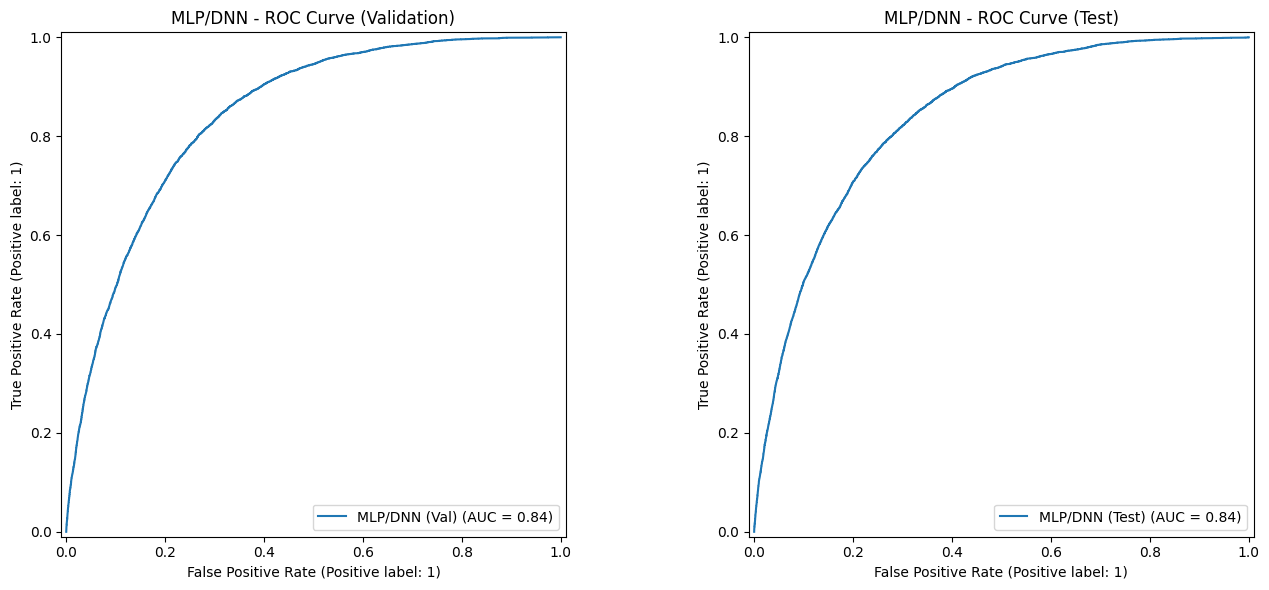

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Validación
RocCurveDisplay.from_predictions(
    y_val, y_val_proba,
    name='MLP/DNN (Val)', ax=axes[0]
)
axes[0].set_title('MLP/DNN - ROC Curve (Validation)')

# Test
RocCurveDisplay.from_predictions(
    y_test, y_test_proba,
    name='MLP/DNN (Test)', ax=axes[1]
)
axes[1].set_title('MLP/DNN - ROC Curve (Test)')

plt.tight_layout()
plt.show()

### 7.4. Curvas Precision–Recall

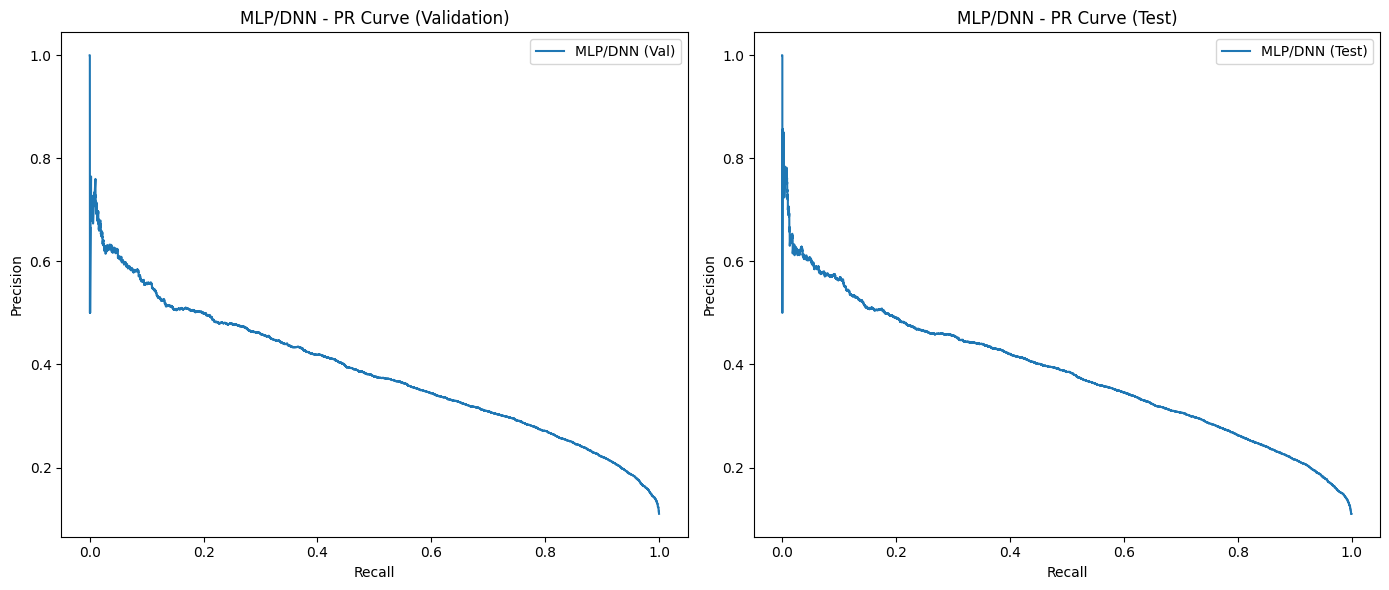

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Validación
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
axes[0].plot(recall_val, precision_val, label='MLP/DNN (Val)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('MLP/DNN - PR Curve (Validation)')
axes[0].legend()

# PR Curve - Test
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recall_test, precision_test, label='MLP/DNN (Test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('MLP/DNN - PR Curve (Test)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.5. Selección de threshold óptimo (Fβ con β=2)

In [28]:
beta = 2  # Prioriza recall sobre precision
thresholds = np.linspace(0, 1, 100)
f2_scores_val = []

for thresh in thresholds:
    y_pred_thresh = (y_val_proba >= thresh).astype(int)
    f2_scores_val.append(fbeta_score(y_val, y_pred_thresh, beta=beta))

best_idx = np.argmax(f2_scores_val)
best_threshold = thresholds[best_idx]
print(f"Threshold óptimo según F2 (Validation): {best_threshold:.3f}")

Threshold óptimo según F2 (Validation): 0.465


### 7.6. Matrices de confusión (Test set)

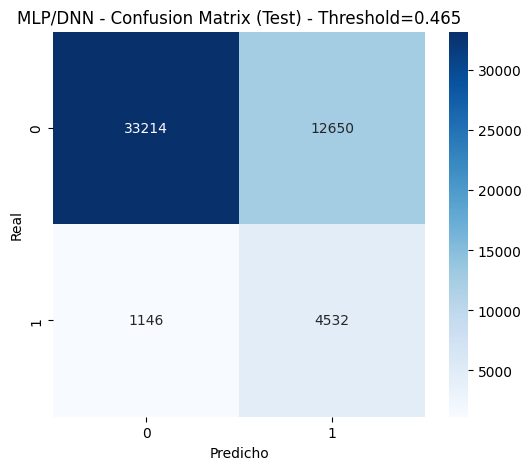

In [29]:
y_test_pred = (y_test_proba >= best_threshold).astype(int)
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title(f'MLP/DNN - Confusion Matrix (Test) - Threshold={best_threshold:.3f}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### 7.7. Resultados finales con threshold óptimo

In [30]:
threshold = best_threshold
y_pred_test = (y_test_proba >= threshold).astype(int)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)

final_results = {
    'Model': 'MLP/DNN',
    'Threshold': threshold,
    'Recall': recall_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'F1-score': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
    'PR-AUC': auc(recall_vals, precision_vals)
}

df_final_results = pd.DataFrame([final_results])
display(df_final_results)

,Model,Threshold,Recall,Precision,F1-score,ROC-AUC,PR-AUC
0,MLP/DNN,0.464646,0.798168,0.263764,0.3965,0.838498,0.383526
